# 02 — XGBoost

Standalone notebook. Run `00_Preprocessing.ipynb` first.

In [1]:
import os, time
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

from utils import PROCESSED_DIR, RESULTS_DIR, MODELS_DIR, PLOTS_DIR, evaluate, save_results

SEED = 42
MODEL_NAME = "XGBoost"


## Load Preprocessed Data

In [2]:
X_train_res = np.load(os.path.join(PROCESSED_DIR, "X_train_res.npy"))
y_train_res = np.load(os.path.join(PROCESSED_DIR, "y_train_res.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))
class_names = joblib.load(os.path.join(PROCESSED_DIR, "class_names.joblib"))
n_classes = joblib.load(os.path.join(PROCESSED_DIR, "n_classes.joblib"))

print(f"Train: {X_train_res.shape}, Test: {X_test.shape}, classes: {n_classes}")


Train: (911664, 78), Test: (53582, 78), classes: 15


## Train

In [3]:
model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    objective="multi:softprob", num_class=n_classes,
    eval_metric="mlogloss", n_jobs=-1, random_state=SEED,
)

t0 = time.time()
model.fit(X_train_res, y_train_res)
train_time = time.time() - t0
print(f"Train time: {train_time:.2f}s")


Train time: 428.32s


## Predict & Evaluate

In [4]:
t0 = time.time()
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
infer_time = time.time() - t0

row = evaluate(MODEL_NAME, y_test, y_pred, y_proba, train_time, infer_time, n_classes)
for k, v in row.items():
    if k not in ("Confusion Matrix",):
        print(f"{k}: {v}")


Model: XGBoost
Accuracy: 0.9985069612929716
Precision: 0.7558802433845794
Recall: 0.7706437465150261
F1-Score: 0.7625438951515919
ROC-AUC: nan
MCC: 0.995359355398137
Cohen's Kappa: 0.9953576378519124
Train Time (s): 428.3230767250061
Prediction Time (s): 2.0010018348693848


## Confusion Matrix Plot

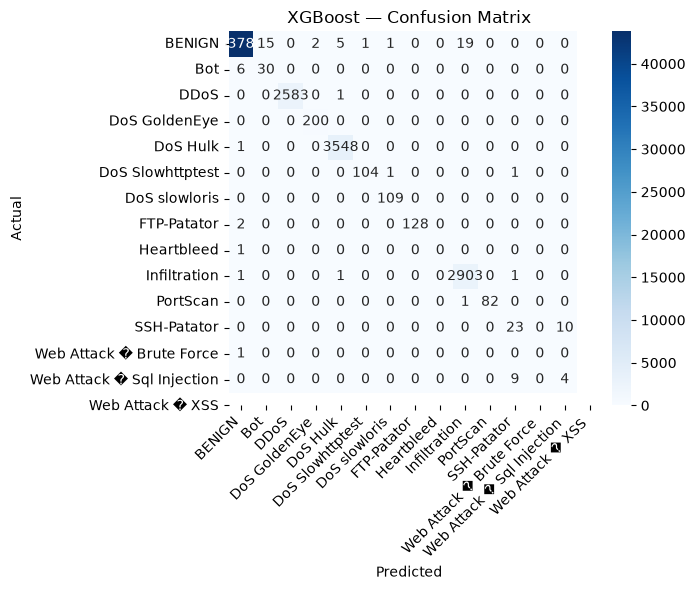

In [5]:
cm = np.array(row["Confusion Matrix"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{MODEL_NAME} — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "XGBoost_confusion_matrix.png"), dpi=150)
plt.show()


## Save Results & Model

In [6]:
save_results(MODEL_NAME, row)
joblib.dump(model, os.path.join(MODELS_DIR, "XGBoost.joblib"))
print("Saved model and results for", MODEL_NAME)


Saved results to results\XGBoost_results.json
Saved model and results for XGBoost
